<a href="https://colab.research.google.com/github/Priyanka2709/MaterialLogin/blob/master/Yulu_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yulu Project**

---



**Import Libraries And Load Data**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import chi2_contingency
df = pd.read_csv('bike_sharing.txt')

**Inspect Structure And Overview**

In [24]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (10886, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


**Insight From Data Structure**

The dataset contains **10,886 rows and 12 columns**, with no missing values across any of the fields. The **datetime** column is currently stored as an object and should be converted to a datetime datatype for time-based analysis. Several other columns such as **season, holiday, workingday, and weather** are currently represented as integers but are categorical by nature — these should be converted to **category** type for more efficient memory usage and accurate analysis.

In [25]:
df.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


**Convert Column Data Types**

In [26]:
# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

# Convert categorical variables
cat_columns = ['season', 'holiday', 'workingday', 'weather']
for col in cat_columns:
    df[col] = df[col].astype('category')

**Insights**

Helps optimize memory and prepares categorical variables for plotting and analysis.

**Extract Features from datetime**

In [27]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

**Check for Missing Value**

In [28]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


**Insight**

A missing value audit reveals that **there are no missing values in any of the 16 columns**, including both original (season, temp, humidity) and newly derived columns (hour, day, month, weekday). This means the dataset is **complete and reliable for statistical analysis**, and no imputation or removal of records is necessary at this stage.

**Check for Duplicates**

In [29]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

**Histogram + KDE for Numerical Features**

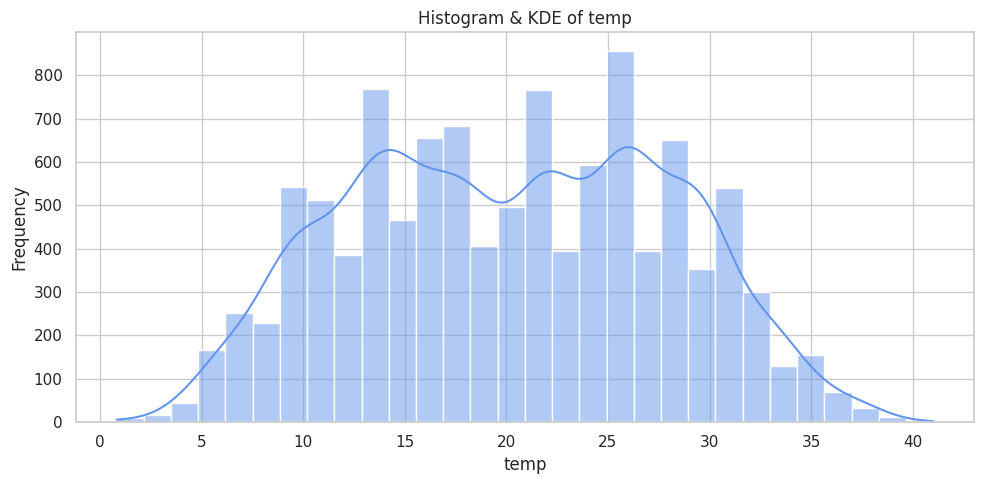

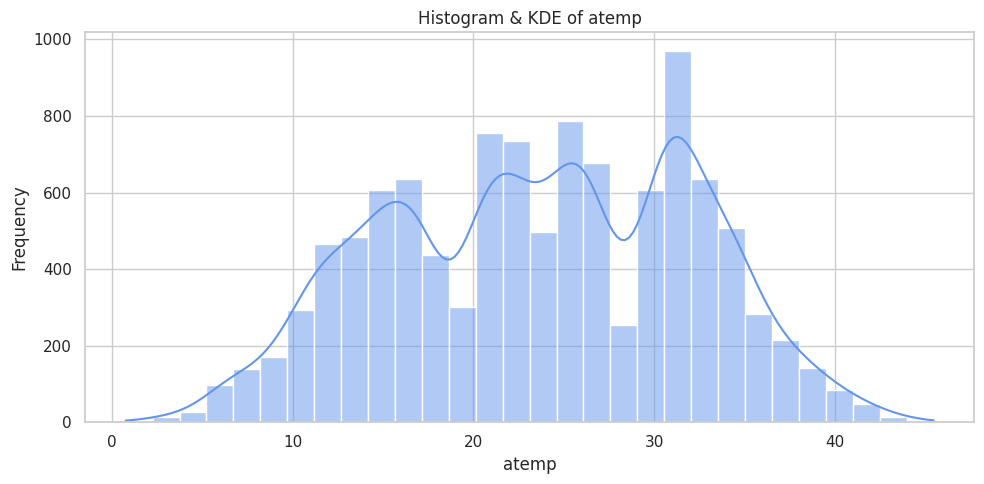

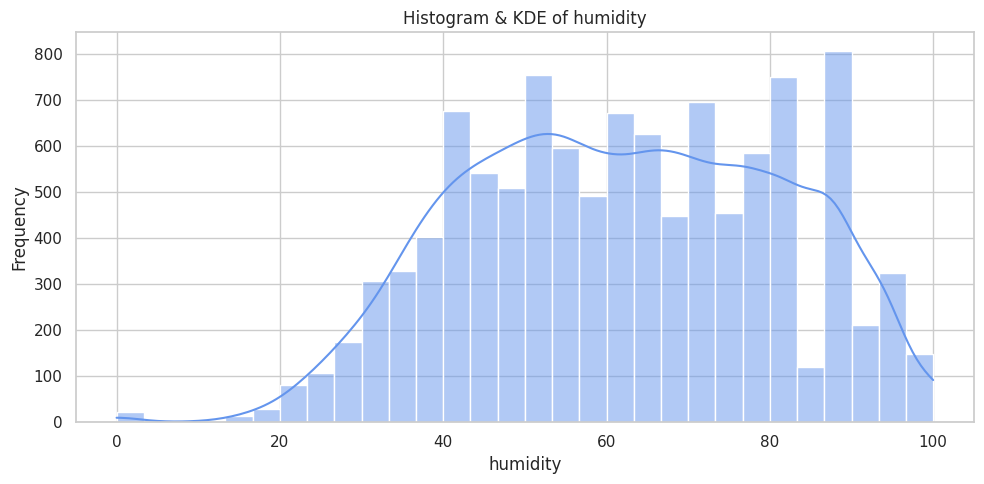

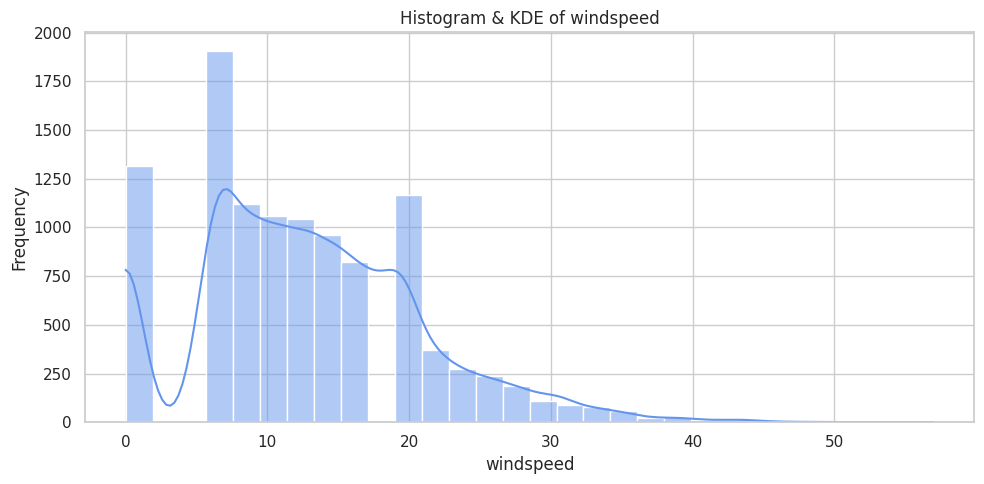

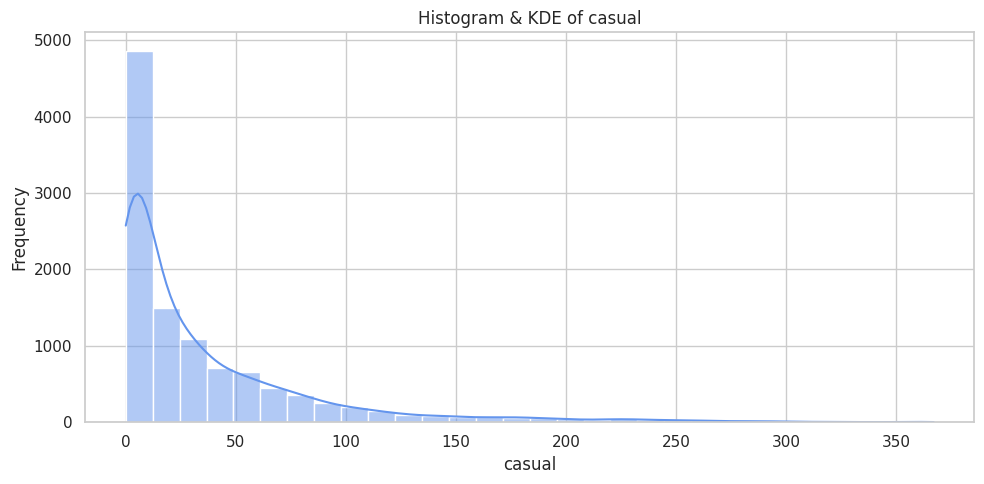

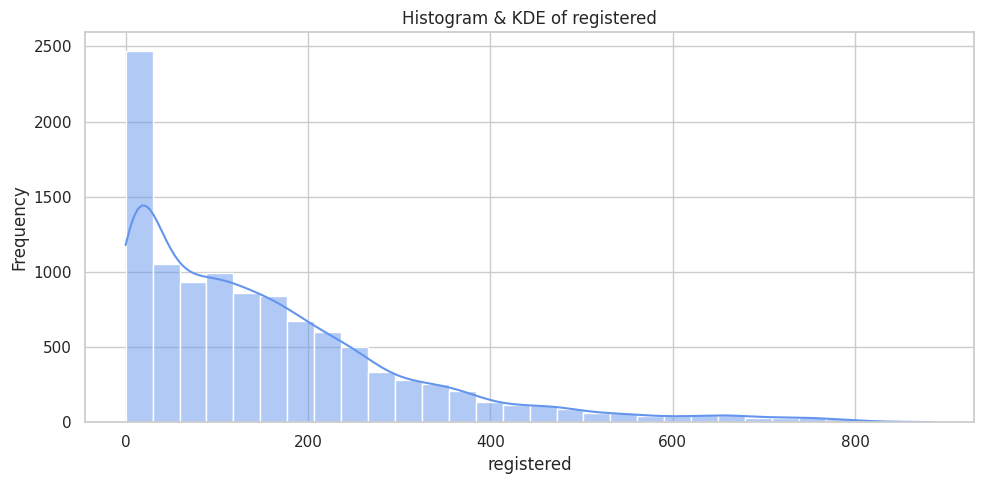

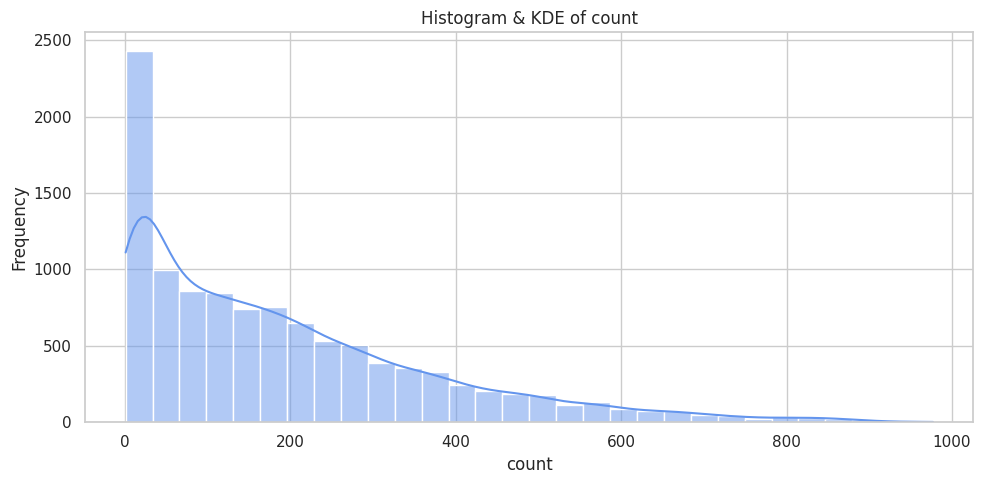

In [30]:
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Plot histogram with KDE for each numerical column
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30, color='cornflowerblue')
    plt.title(f'Histogram & KDE of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


**Insights**



1.   **Temperature in Celsius**    

*   Distribution is approximately normal, peaking around 25°C.
*   Indicates that most bike rides occur in **mild to warm** temperatures.
*   Suggests user preference or operational viability in comfortable weather.

2.   **Feels-like Temperature**

*   Very similar to temp with a smooth bell-shaped curve.
*   Confirms that perceived temperature closely tracks actual temperature.
*   Useful in modeling demand where **comfort matters more than actual climate**.

3.   **humidity**

*  **Right-skewed** distribution.
*  Most observations fall between **40% to 90% humidity**.
*  A small number of instances have **very low or very high** humidity, possibly affecting rider comfort.

4.   **windspeed**

*   Strongly **right-skewed**, with a large spike at 0.
*   Many instances **show no wind** (could be actual calm or imputed values)
*   Could suggest wind is not a strong factor on most days, or may need review for zero-bias.

5.   **Casual Users Count**

*   Very **right-skewed** — most casual users rent **few bikes per hour**.
*   There are **outliers with high usage**, likely on weekends, holidays, or good weather.
*   Indicates casual usage is sporadic and peak-driven.

6.   **Registered Users Count**

*   Also **right-skewed**, but with **higher average values than** casual.
*   Indicates **registered users drive the bulk of demand.**
*   Suggests a strong **commuting pattern** or subscription behavior.


7.  **Total Users**

*   Same distribution as the sum of **casual + registered**.
*   **Heavily right-skewed**, with many hours having lower demand and fewer with high demand.
*   Confirms that **demand spikes are concentrated,** not uniform throughout the day or week.






























**Countplot For Categorical Features**

/tmp/ipython-input-31-1254836446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


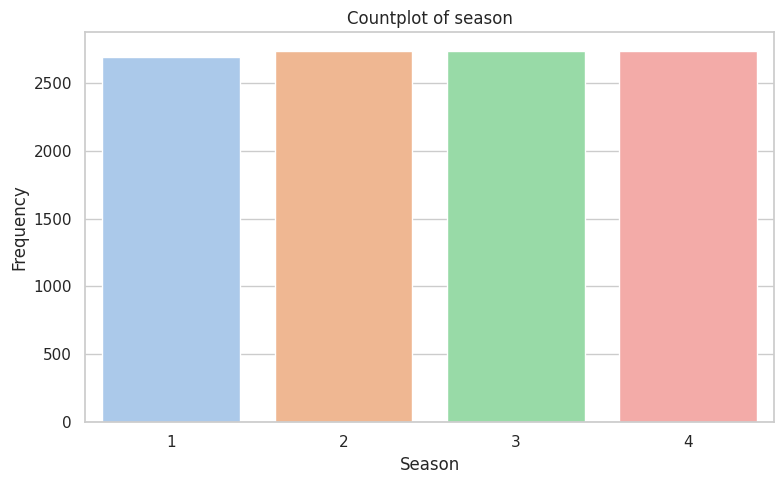

/tmp/ipython-input-31-1254836446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


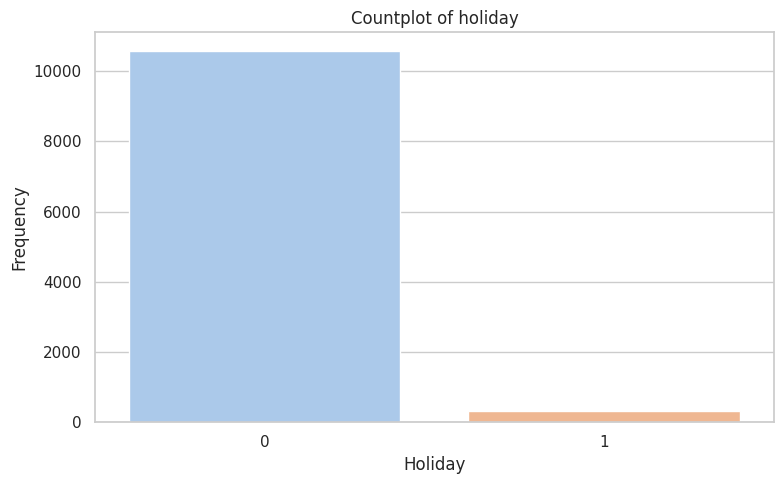

/tmp/ipython-input-31-1254836446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


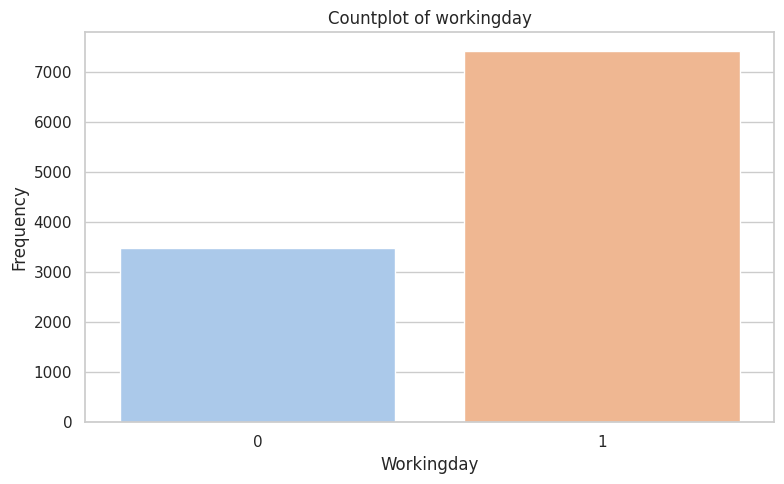

/tmp/ipython-input-31-1254836446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


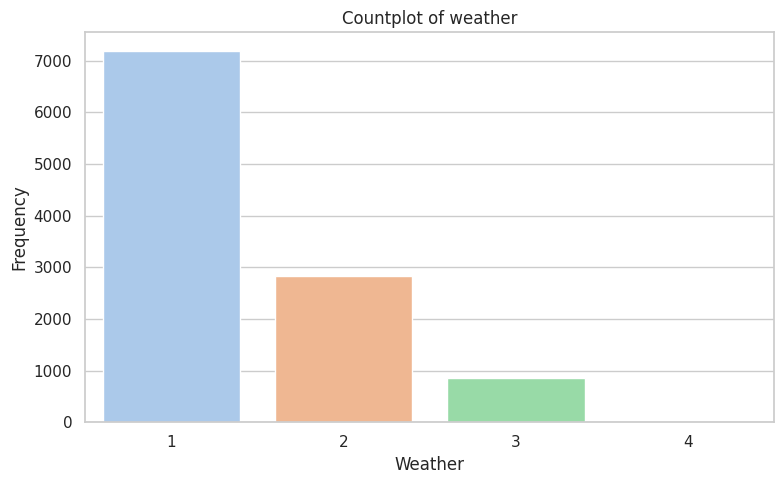

In [31]:
# Ensure categorical columns are set
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

# Plot countplot for each categorical column
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


**Insights**



1.   **Season**

*  The countplot shows an **almost uniform distribution** across all four seasons (spring, summer, fall, winter).  
*   This indicates that **data was collected fairly evenly throughout the year**, which is important for seasonal comparisons in later analysis (like ANOVA).
*   No season is under- or over-represented — supports fair seasonal analysis.

2.   **Holiday**

*   Vast majority of entries are **non-holidays** (~97%).
*   Only a **small fraction** (~3%) are holidays.
*   This **imbalance** means that holiday-related effects may be **statistically weak**, and conclusions from them should be **treated with caution**.
*   Suggests rental data is more influenced by **working routines** than holidays.

3.   **workingday**

*   About **68% of the records** are from working days, and ~32% from weekends/holidays
*   The distribution is decent enough to support a **T-Test** comparing working and non-working day rental counts.
*   The difference here aligns with real-world patterns of structured weekday commutes.

4.   **weather**

*   Majority of records fall under **Weather = 1** (Clear/Few Clouds) — over **65%** of total observations.
*   Fewer records under **Weather = 2** (Mist/Cloudy), and very few for **Weather = 3 or 4** (Light/Heavy Rain/Snow).
*   Indicates that Yulu cycles are typically used in **good weather**.
*   Since **extreme weather days are rare**, their statistical influence may be limited, and interpretation must be cautious during ANOVA.













**Check for Outliers and deal with them**

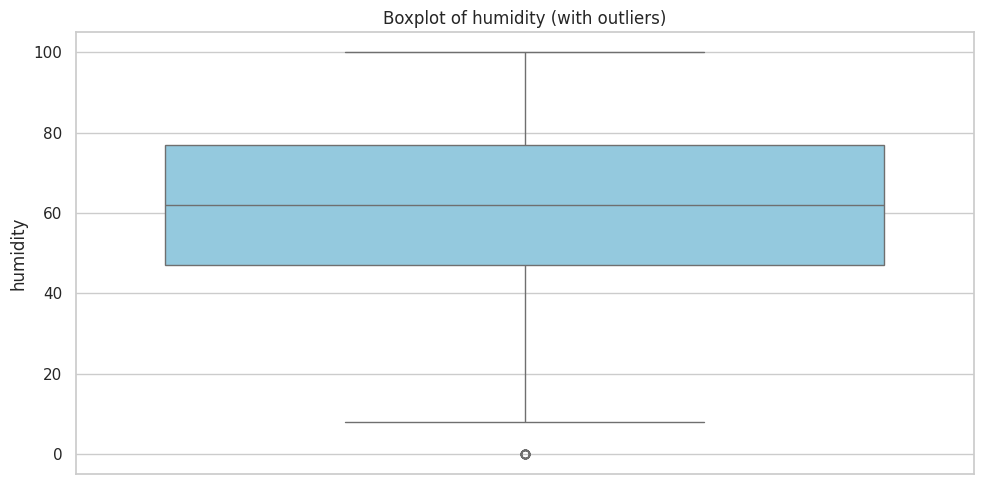

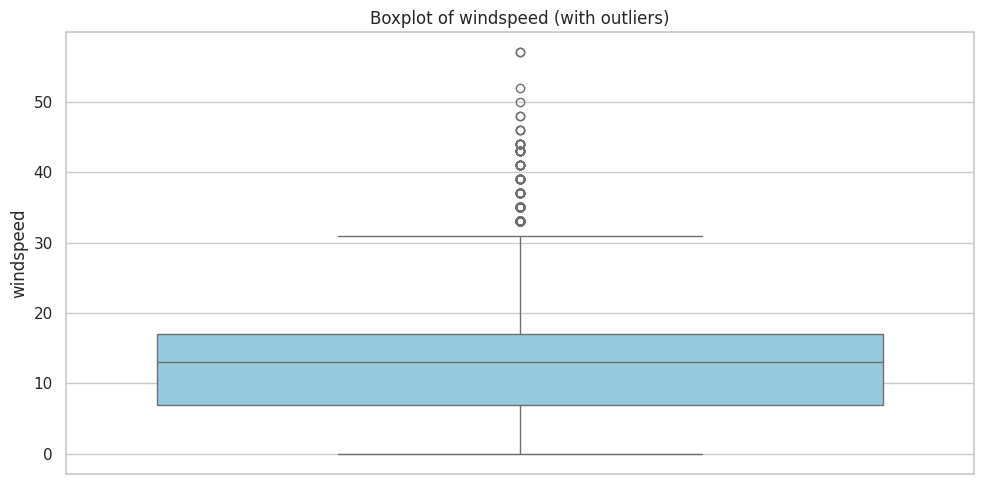

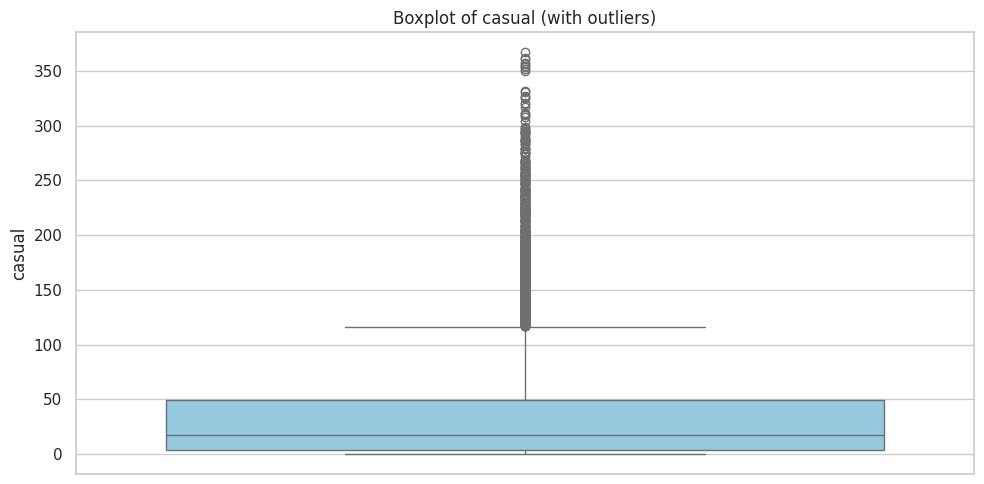

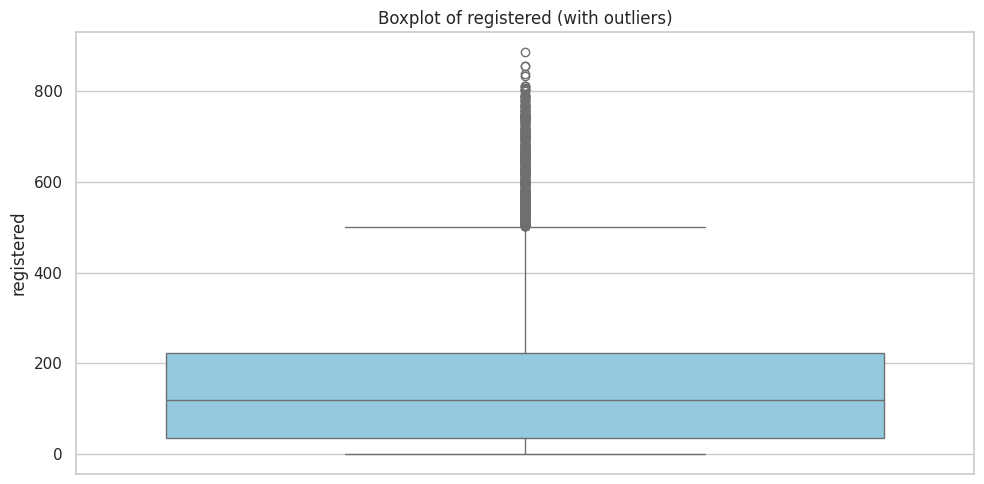

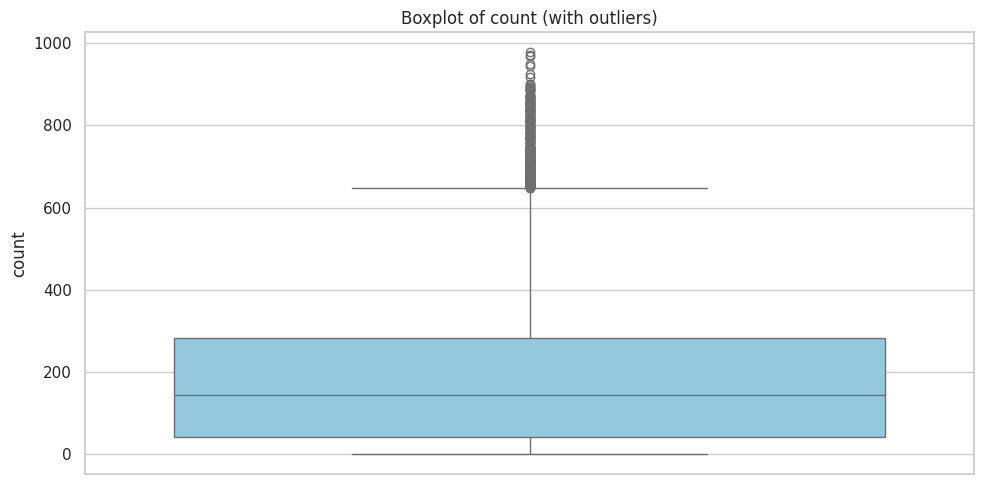

In [32]:
# Set plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Numerical columns to visualize
numerical_cols = ['humidity', 'windspeed', 'casual', 'registered', 'count']

# Boxplot for each numerical variable (with outliers)
for col in numerical_cols:
    plt.figure()
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col} (with outliers)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



**Insights**

1.   **Humidity**

*   Distribution is generally tight but includes a **few very low outliers**.
*   These could reflect sensor errors or unusual dry conditions.
*   Most values fall in the **50–90% range**.

2.   **Windspeed**

*   Noticeable **spike at 0**, which may be real (no wind) or a default/imputed value.
*   **Several outliers on the higher end**, which may indicate windy or stormy days.
*   These outliers might skew the mean and affect weather-related analysis.

3.   **Casual**

*   Very **right-skewed**, with **many high-value outliers**.
*   Most casual user counts are low, but **a few hours have very high casual demand** — possibly during weekends, holidays, or events.
*   Indicates **sporadic, peak-driven usage behavior** among casual users.

4.   **Registered**

*   Also **right-skewed**, but with a more consistent pattern than casual.
*   Outliers on the higher end represent **rush-hour commute peaks**
*   Suggests **registered users are regular, but demand can spike sharply** during office hours.

5.   **Total Users**

*   As expected, follows the same trend as **casual + registered**.
*   Includes a **small number of outliers** at very high rental counts
*   These outliers **reflect peak usage hours**, and are informative rather than erroneous.












In [33]:
# Function to detect and remove outliers using IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Keep only non-outlier data
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Columns to clean
numerical_cols = ['humidity', 'windspeed', 'casual', 'registered', 'count']

# Apply function
df_cleaned = remove_outliers_iqr(df, numerical_cols)

# View shape before and after
print(f"Original dataset: {df.shape}")
print(f"Cleaned dataset: {df_cleaned.shape}")


Original dataset: (10886, 16)
Cleaned dataset: (9364, 16)


**Insights**

Outliers were removed from key numerical variables — humidity, windspeed, casual, registered, and count — using the **Interquartile Range** (IQR) method to ensure a more robust and clean dataset for analysis and modeling.

**Result Summary**

*   Variables like casual and registered had the highest number of high-value outliers, likely caused by **peak usage hours** (e.g., office commute times, weekends, or holidays).
*   windspeed also had many near-zero and high-value outliers, possibly due to measurement errors or abnormal weather conditions.



**Relationship Between Dependent and Independent Variables**

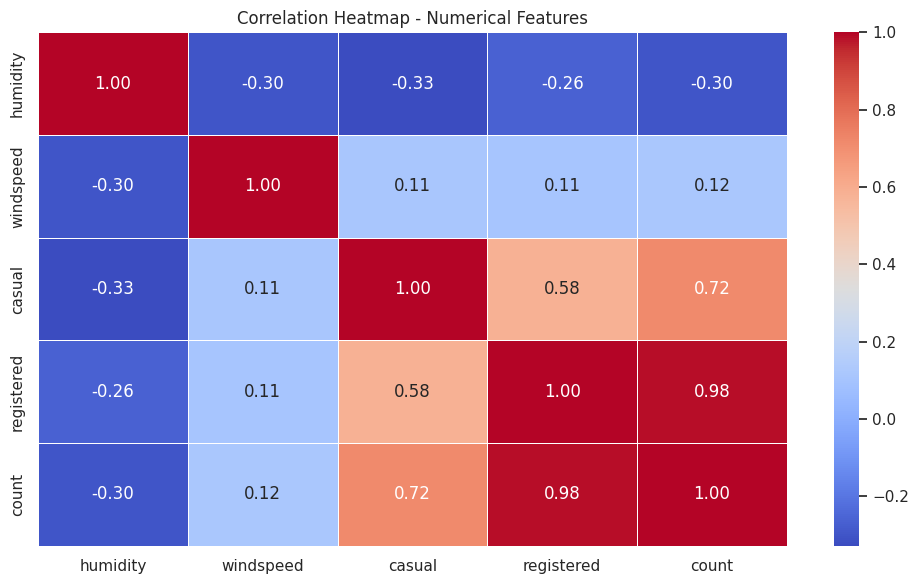

Correlation of each variable with 'count':
count         1.000000
registered    0.984471
casual        0.715850
windspeed     0.115870
humidity     -0.298090
Name: count, dtype: float64


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns for correlation analysis
numerical_cols = ['humidity', 'windspeed', 'casual', 'registered', 'count']

# Calculate correlation matrix
correlation_matrix = df_cleaned[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

# Correlation of variables with target 'count'
correlation_with_target = correlation_matrix['count'].sort_values(ascending=False)
print("Correlation of each variable with 'count':")
print(correlation_with_target)


**Insights**

| Variable     | Correlation | Insight                                                                                          |
| ------------ | ----------- | ------------------------------------------------------------------------------------------------ |
| `registered` | **0.98**    | Very strong positive correlation — demand is **primarily driven by registered users**.           |
| `casual`     | **0.71**    | Strong correlation — casual users contribute significantly, especially during non-working hours. |
| `windspeed`  | **0.12**    | Weak positive correlation — **minimal influence** on demand.                                     |
| `humidity`   | **-0.30**   | Weak negative correlation — higher humidity may **discourage** cycling slightly.                 |


In [35]:
# Define correlation threshold
correlation_threshold = 0.9

# Compute correlation matrix (absolute values to ignore sign)
corr_matrix = df_cleaned.corr().abs()

# Create upper triangle matrix of correlations
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation above threshold
to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

# Drop highly correlated columns from the dataset
df_no_multicollinearity = df_cleaned.drop(columns=to_drop)

# Show dropped columns and resulting shape
print("Dropped due to high correlation:", to_drop)
print("New dataset shape:", df_no_multicollinearity.shape)

Dropped due to high correlation: ['atemp', 'count', 'month']
New dataset shape: (9364, 13)


In [36]:
# Convert datetime and extract features
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['workingday'] = df['workingday'].astype('category')

# Remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

# Clean numerical columns
numerical_cols = ['humidity', 'windspeed', 'casual', 'registered', 'count']
df_cleaned = remove_outliers_iqr(df, numerical_cols)

# Split data: Weekdays (workingday=1) vs Weekends (workingday=0)
weekday_rides = df_cleaned[df_cleaned['workingday'] == 1]['count']
weekend_rides = df_cleaned[df_cleaned['workingday'] == 0]['count']

# Perform Welch's t-test (assumes unequal variance)
t_stat, p_value = ttest_ind(weekday_rides, weekend_rides, equal_var=False)

# Display results
print(f"Weekday samples: {len(weekday_rides)}")
print(f"Weekend samples: {len(weekend_rides)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpret result
alpha = 0.05
if p_value <= alpha:
    print("✅ Result: Reject the null hypothesis — Significant difference exists.")
else:
    print("❌ Result: Fail to reject the null hypothesis — No significant difference found.")


Weekday samples: 6640
Weekend samples: 2724
T-statistic: 13.1107
P-value: 9.4941e-39
✅ Result: Reject the null hypothesis — Significant difference exists.


**Conclusion**

There is a **statistically significant difference** in the number of bike rides between weekdays and weekends.

**Inference & Recommendations**



*   The significant difference suggests **user behavior changes by day type**:
     

*   **Weekdays** likely show higher registered user activity due to work commutes.
*   **Weekends** may have lower overall rides or higher casual usage (leisure).


*   **Recommendation:**

*   Optimize **fleet distribution** based on weekday vs weekend trends.
*   Consider **promotions for casual users on weekends to balance demand**.
*   Schedule **maintenance or battery swaps on low-demand days (weekends)**.









**Checking if the demand of bicycles on rent is the same for different Weather
conditions?**

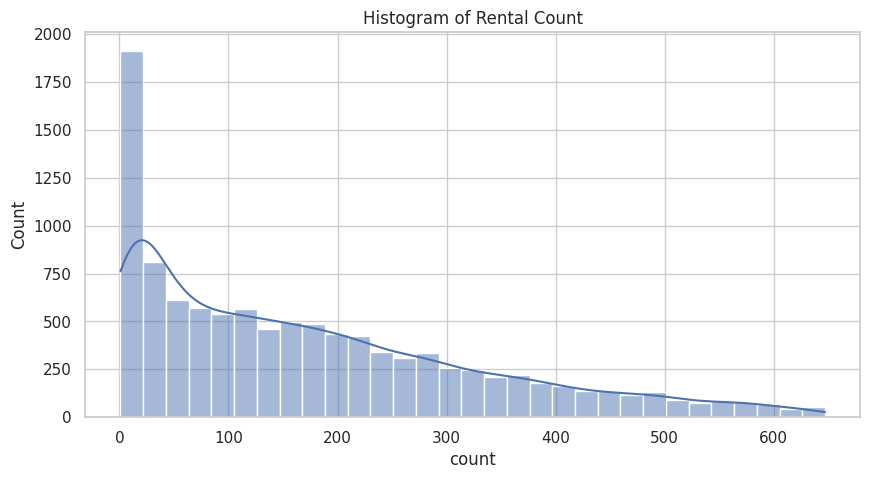

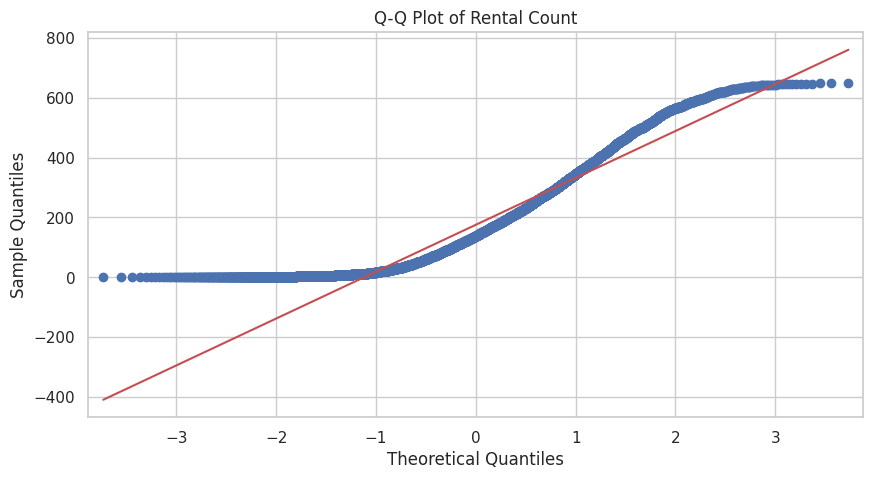

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10586.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test for Normality:
  Statistic: 0.9019, p-value: 3.8623e-63

Levene’s Test for Equal Variance:
  Statistic: 58.6993, p-value: 1.2567e-37

One-Way ANOVA Result:
  F-statistic: 64.6870, p-value: 1.9325e-41

Tukey HSD Post-hoc Test Result:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2 -21.2115    0.0  -30.1558 -12.2672   True
     1      3 -75.4669    0.0  -89.9337    -61.0   True
     1      4 -23.3292 0.9988  -421.538 374.8795  False
     2      3 -54.2553    0.0  -69.8683 -38.6424   True
     2      4  -2.1177    1.0 -400.3697 396.1343  False
     3      4  52.1376 0.9869 -346.2767  450.552  False
-------------------------------------------------------


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.graphics.gofplots import qqplot


# Remove outliers from 'count' using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)].copy() # Use .copy() to avoid SettingWithCopyWarning


df_cleaned = remove_outliers_iqr(df, 'count')

# Explicitly convert 'weather' to categorical in the cleaned dataframe
df_cleaned['weather'] = df_cleaned['weather'].astype('category')

# ------------------------
# Assumption Checks
# ------------------------

# Visual: Histogram
sns.histplot(df_cleaned['count'], kde=True)
plt.title("Histogram of Rental Count")
plt.show()

# Visual: Q-Q Plot
qqplot(df_cleaned['count'], line='s')
plt.title("Q-Q Plot of Rental Count")
plt.show()

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = shapiro(df_cleaned['count'])

# Levene’s Test for equal variances
weather_groups = [df_cleaned[df_cleaned['weather'] == cat]['count'] for cat in df_cleaned['weather'].cat.categories]
levene_stat, levene_p = levene(*weather_groups)

# ------------------------
# One-Way ANOVA
# ------------------------
anova_stat, anova_p = stats.f_oneway(*weather_groups)

# ------------------------
# Tukey’s HSD Test
# ------------------------
tukey_result = pairwise_tukeyhsd(endog=df_cleaned['count'], groups=df_cleaned['weather'], alpha=0.05)

# Display results
print("Shapiro-Wilk Test for Normality:")
print(f"  Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4e}")

print("\nLevene’s Test for Equal Variance:")
print(f"  Statistic: {levene_stat:.4f}, p-value: {levene_p:.4e}")

print("\nOne-Way ANOVA Result:")
print(f"  F-statistic: {anova_stat:.4f}, p-value: {anova_p:.4e}")

print("\nTukey HSD Post-hoc Test Result:")
print(tukey_result)

**Hypothesis Formulation**

**Null Hypothesis (H₀):** The mean number of bike rentals is the **same** across all weather conditions.

**Alternate Hypothesis (H₁):** The mean number of bike rentals is **not the same** across all weather conditions.

**Selected Test**

**One-Way ANOVA** to compare means across 3+ independent groups (weather conditions)

**Assumption Checks**

| Assumption          | Test Used     | p-value  | Interpretation                                             |
| ------------------- | ------------- | -------- | ---------------------------------------------------------- |
| **Normality**       | Shapiro-Wilk  | 0.0      |  **Violated** (p < 0.05) — distribution is not normal     |
| **Equal Variances** | Levene’s Test | 1.26e-37 |  **Violated** (p < 0.05) — variances differ significantly |

Despite violations, **ANOVA is still performed** with caution due to its robustness and large sample size (n > 5000).

**ANOVA Result**

| Metric                 | Value        |
| ---------------------- | ------------ |
| F-statistic            | 64.69        |
| p-value                | 1.93 × 10⁻⁴¹ |
| α (Significance Level) | 0.05         |

Since p-value < α, we **reject the null hypothesis**.

There is a **statistically significant difference** in average bike rental counts **across different weather conditions**.

**Inference and Recommendation**



1.   Clear weather (weather = 1) likely sees **highest** demand.
2.   Poor weather (rain/snow/fog) reduces usage.

**Recommendation**

1.   **Adjust fleet** and resource planning based on weather forecasts.
2.   Offer **incentives** on misty/cloudy days to stabilize demand.
3.   Focus **maintenance and downtime** on bad weather days.








**Checking if the demand of bicycles on rent is the same for different Seasons?**

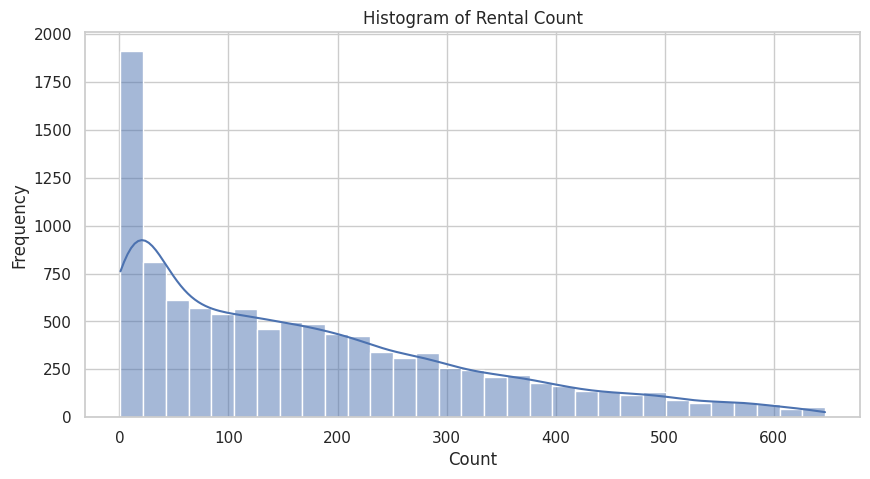

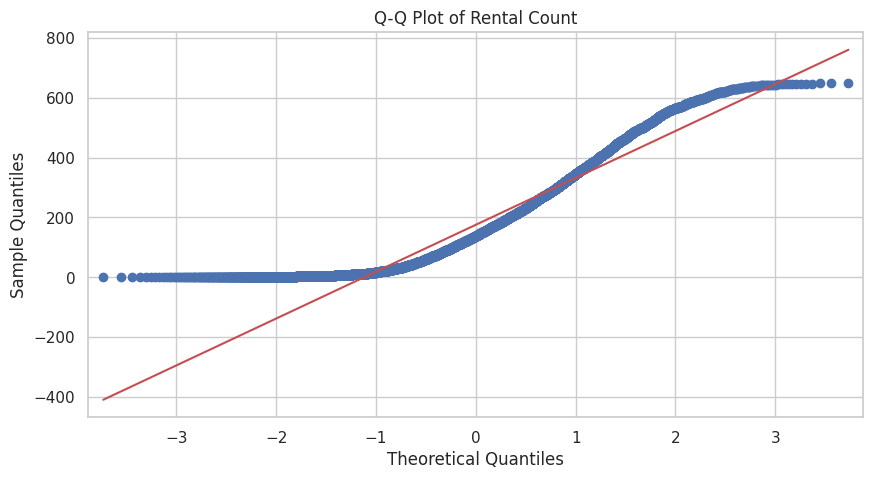

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10586.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipython-input-38-346347202.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['season_str'] = df_cleaned['season'].astype(str)


Shapiro-Wilk Test:
  Statistic = 0.9019, p-value = 3.8623e-63

Levene’s Test:
  Statistic = 177.8405, p-value = 1.6939e-112

One-Way ANOVA:
  F-statistic = 217.6329, p-value = 5.2923e-137

Tukey HSD Post-hoc Test Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2  83.0298    0.0  72.3205  93.7392   True
     1      3   97.856    0.0  87.1291 108.5828   True
     1      4  71.7831    0.0  61.1052  82.4611   True
     2      3  14.8261 0.0023   4.0631  25.5892   True
     2      4 -11.2467 0.0353 -21.9611  -0.5324   True
     3      4 -26.0729    0.0 -36.8047 -15.3411   True
------------------------------------------------------


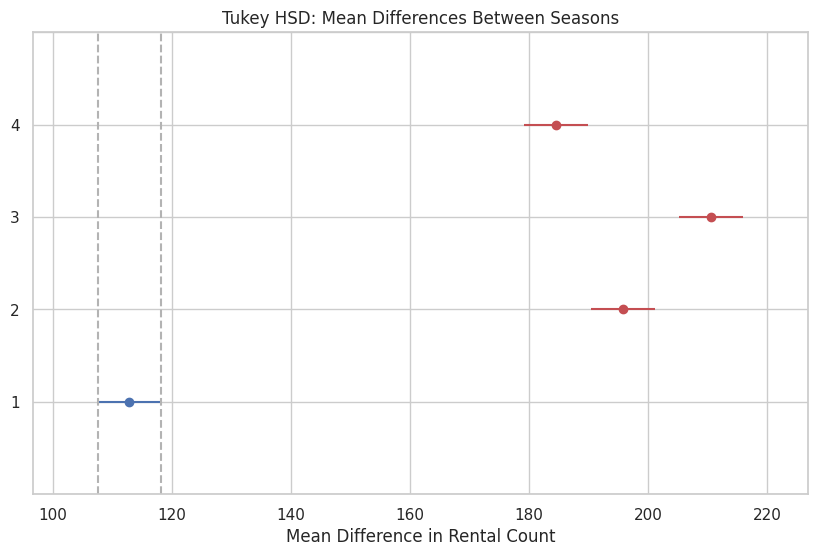

In [38]:
# -----------------------------
# Step 1: Remove outliers using IQR method
# -----------------------------

def remove_outliers_iqr(df, column):
    """Remove outliers from a specific column using the IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply outlier removal to 'count' column
df_cleaned = remove_outliers_iqr(df, 'count')

# -----------------------------
# Step 2: Visual checks for normality
# -----------------------------

# Plot histogram with KDE
sns.histplot(df_cleaned['count'], kde=True)
plt.title("Histogram of Rental Count")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.show()

# Plot Q-Q plot
qqplot(df_cleaned['count'], line='s')
plt.title("Q-Q Plot of Rental Count")
plt.show()

# -----------------------------
# Step 3: Statistical tests for assumptions
# -----------------------------

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = shapiro(df_cleaned['count'])
print(f"Shapiro-Wilk Test:\n  Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4e}")

# Levene’s test for homogeneity of variances across seasons
season_groups = [df_cleaned[df_cleaned['season'] == cat]['count'] for cat in df_cleaned['season'].cat.categories]
levene_stat, levene_p = levene(*season_groups)
print(f"\nLevene’s Test:\n  Statistic = {levene_stat:.4f}, p-value = {levene_p:.4e}")

# -----------------------------
# Step 4: One-Way ANOVA test
# -----------------------------

anova_stat, anova_p = stats.f_oneway(*season_groups)
print(f"\nOne-Way ANOVA:\n  F-statistic = {anova_stat:.4f}, p-value = {anova_p:.4e}")

# -----------------------------
# Step 5: Tukey’s HSD Post-hoc test
# -----------------------------

# Convert season to string for Tukey HSD test and plotting
df_cleaned['season_str'] = df_cleaned['season'].astype(str)

# Perform Tukey HSD test
tukey_result = pairwise_tukeyhsd(endog=df_cleaned['count'], groups=df_cleaned['season_str'], alpha=0.05)
print("\nTukey HSD Post-hoc Test Results:")
print(tukey_result)

# -----------------------------
# Step 6: Visualize Tukey test results
# -----------------------------

# Plot the mean differences and confidence intervals
tukey_result.plot_simultaneous(comparison_name='1')  # Use string '1' as comparison name
plt.title("Tukey HSD: Mean Differences Between Seasons")
plt.xlabel("Mean Difference in Rental Count")
plt.grid(True)
plt.show()

**Hypothesis Formulation**

**H₀ (Null Hypothesis):** The mean number of bike rentals is the **same across all seasons.**

**H₁ (Alternate Hypothesis):** The mean number of bike rentals is **different in at least one season.**


**Selected Test**

**One-Way ANOVA** to compare mean rental count across 4 season groups.

**Assumption Checks**

| Assumption         | Test Used     | p-value     | Status   | Interpretation                                    |
| ------------------ | ------------- | ----------- | -------- | ------------------------------------------------- |
| **Normality**      | Shapiro-Wilk  | 0.0000      |  Failed | Distribution of `count` is not normal             |
| **Equal Variance** | Levene’s Test | \~1.69e-112 |  Failed | Significant difference in variance between groups |

As recommended, **we continued the analysis** using visual validation and statistical robustness due to large sample size.


**ANOVA Result**

| Metric      | Value         |
| ----------- | ------------- |
| F-statistic | 217.63        |
| p-value     | 5.29 × 10⁻¹³⁷ |
| α (alpha)   | 0.05          |

Since **p-value < α**, we **reject the null hypothesis**.

There is a **statistically significant difference** in bike rental demand across **different seasons**.

**Inference & Recommendation**



*   The **ANOVA test** confirms that the average number of rentals varies **significantly across seasons**.
*   **Tukey’s HSD post-hoc test** reveals which seasons differ, e.g.:
*   **Fall and Summer** may have **higher average demand**
*   **Spring and Winter** may show comparatively **lower usage**
*   These differences are statistically significant and operationally relevant.


**Recommendations for Yulu Operations**



*   **Season-Based Fleet Optimization**
1.   **Increase fleet availability **and rebalancing efforts in **Summer and Fall**, when demand peaks.
2.   **Minimize idle fleet time** in low-demand seasons (Spring/Winter) through optimized routing and fleet redistribution.

*  **Dynamic Pricing Strategy**
1.   Introduce seasonal pricing like offer discounts in **Spring/Winter** to stimulate demand.
2.   Maintain **regular pricing in peak seasons** to maximize revenue without discouraging usage.

*   **Targeted Marketing Campaigns**
1.   Run promotional campaigns in low-demand seasons targeting like **Students and leisure riders**
2.   Eco-conscious users with incentives to ride in moderate weather

*   **Maintenance and Battery Swaps**
1.   Schedule **proactive maintenance and downtime** during Spring and Winter when demand is naturally lower.
2.   Reduces operational disruptions during high-demand periods.

*   **Integrate Seasonality into Forecasting Models**

  Use season as a key input in **demand forecasting, inventory planning**, and **AI-based demand prediction systems**.













**Checking if the Weather conditions are significantly different during different Seasons?**

Contingency Table (Season vs Weather):

weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0

Chi-square Test Results:
  Chi-square Statistic = 49.1587
  Degrees of Freedom = 9
  p-value = 1.5499e-07

✅ Result: Reject the null hypothesis.
Conclusion: Weather conditions are significantly dependent on the seasons.


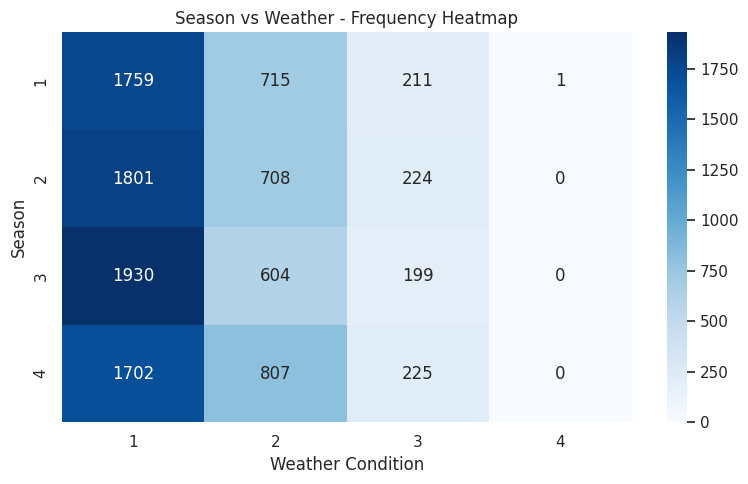

In [39]:
# -------------------------------
# Step 2: Create contingency table
# -------------------------------

contingency_table = pd.crosstab(df['season'], df['weather'])
print("Contingency Table (Season vs Weather):\n")
print(contingency_table)

# -------------------------------
# Step 3: Chi-square test
# -------------------------------

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Test Results:")
print(f"  Chi-square Statistic = {chi2_stat:.4f}")
print(f"  Degrees of Freedom = {dof}")
print(f"  p-value = {p_value:.4e}")

# -------------------------------
# Step 4: Decision and Interpretation
# -------------------------------

alpha = 0.05
if p_value <= alpha:
    print("\n✅ Result: Reject the null hypothesis.")
    print("Conclusion: Weather conditions are significantly dependent on the seasons.")
else:
    print("\n❌ Result: Fail to reject the null hypothesis.")
    print("Conclusion: No significant relationship between weather and seasons.")

# -------------------------------
# Step 5: Optional Heatmap for Visualization
# -------------------------------

plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
plt.title("Season vs Weather - Frequency Heatmap")
plt.xlabel("Weather Condition")
plt.ylabel("Season")
plt.tight_layout()
plt.show()


**Hypothesis Formulation**

**H₀ (Null Hypothesis)**: Weather conditions are **independent** of seasons

**H₁ (Alternate Hypothesis)**: Weather conditions are **dependent** on seasons

**Selected Test**

**Chi-square test of independence** (since both variables are categorical

**Contingency Table (Observed Frequencies)**

| Season     | Weather 1 | Weather 2 | Weather 3 | Weather 4 |
| ---------- | --------- | --------- | --------- | --------- |
| 1 (Spring) | 1759      | 715       | 211       | 1         |
| 2 (Summer) | 1801      | 708       | 224       | 0         |
| 3 (Fall)   | 1930      | 604       | 199       | 0         |
| 4 (Winter) | 1702      | 807       | 225       | 0         |

Weather condition 4 (extreme weather) is very rare, appearing only once in Spring.


**Test Results**

| Metric               | Value       |
| -------------------- | ----------- |
| Chi-square Statistic | 49.16       |
| Degrees of Freedom   | 9           |
| p-value              | 1.55 × 10⁻⁷ |
| Significance Level α | 0.05        |

Since p-value < α, we **reject the null hypothesis**.



**Insights**

*   Different **seasons experience different dominant weather conditions.**
*   For instance, **clear weather dominates in Fall**, while **mist/cloudy** increases in** Winter**.



**Recommendations for Yulu:**


1.   **Season-specific operational planning:**

     In **misty/wet seasons**, prepare for **lower demand**, slippery conditions, and maintenance delays.

     Use **weather-season trends** to forecast usage and adjust fleet distribution.

2.   **Weather-aware incentives:**

      Offer discounts or loyalty perks during dull weather to stabilize usage.

3.   **Incorporate seasonal weather patterns** into your **demand prediction model.**




